# Weather + Crime RNN


Processing city: Charlottesville


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MAE: 3.34, RMSE: 4.26, R²: 0.022


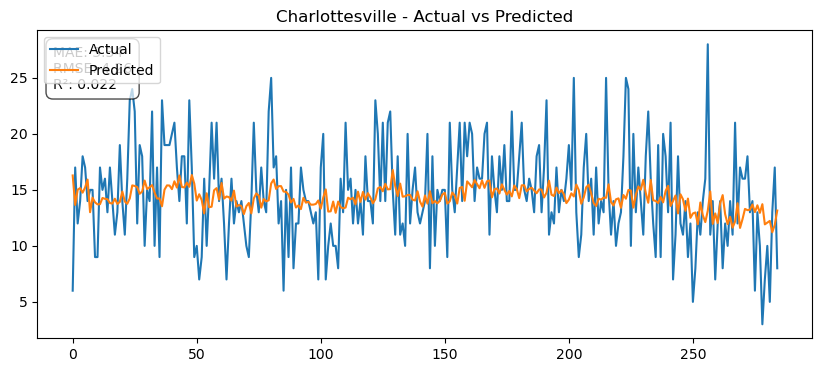


Processing city: Chicago


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
MAE: 47.56, RMSE: 59.40, R²: 0.253


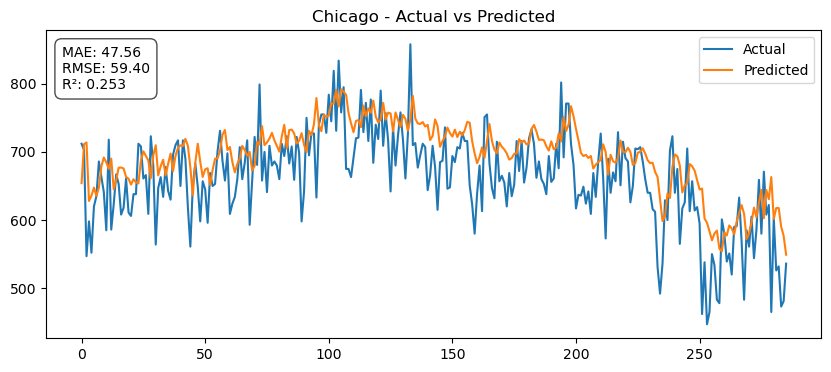


Processing city: Durham


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
MAE: 10.52, RMSE: 13.61, R²: 0.136


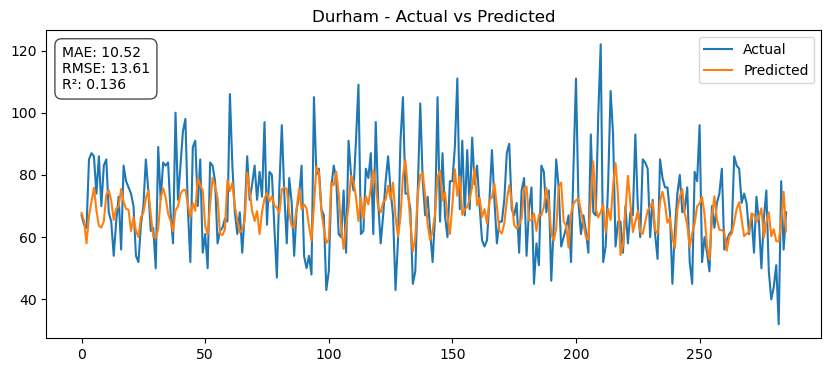


Processing city: NYC


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MAE: 74.64, RMSE: 103.98, R²: 0.544


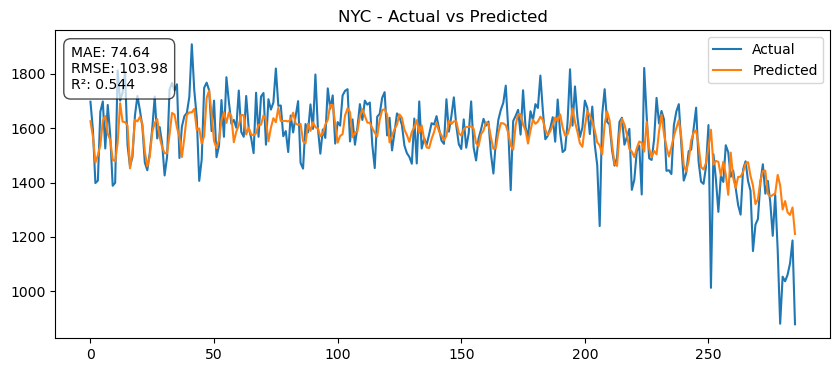


Overall Performance:
MAE     34.013521
RMSE    45.311580
R2       0.238942
dtype: float64

Per-City Results:
              city        MAE        RMSE        R2
0  Charlottesville   3.344824    4.258894  0.022487
1          Chicago  47.557486   59.404780  0.253456
2           Durham  10.515375   13.606187  0.135760
3              NYC  74.636398  103.976458  0.544065


In [83]:
import os
# to help reproducability
import random
random.seed(42)
import numpy as np
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = str(42)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import tensorflow as tf
tf.random.set_seed(42)
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
import matplotlib.pyplot as plt

# original features
features = ['total_crime_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']

# load data
df = pd.read_csv("weather_crime_final.csv")
df['date'] = pd.to_datetime(df['date'])

# lag the weather 1 day, drop nans caused by lag
df[f'temp_lag'] = df['Daily Temperature Mean'].shift(1)
df[f'precip_lag'] = df['Daily Precipitation Sum'].shift(1)
df = df.dropna().reset_index(drop=True)

features = ['total_crime_count', 'temp_lag', 'precip_lag']

# helper functions
# create time sequences for RNN
def create_sequences(data, target_idx, seq_length=14):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_idx])
    return np.array(X), np.array(y)

# build the RNN model
def build_model(input_shape):
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# convert scaled predictions back to original values
def inverse_transform(preds, scaler, target_idx, n_features):
    temp = np.zeros((len(preds), n_features))
    temp[:, target_idx] = preds.flatten()
    return scaler.inverse_transform(temp)[:, target_idx]

# evaluate model performance
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# process each city 
def process_city(city_df):
    # train test split
    split = int(len(city_df) * 0.8)
    train, test = city_df.iloc[:split], city_df.iloc[split:]

    # scale features using MinMaxScaler
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[features])
    test_scaled = scaler.transform(test[features])

    # create sequences for RNN input
    target_idx = features.index('total_crime_count')
    X_train, y_train = create_sequences(train_scaled, target_idx, seq_length=SEQ_LENGTH)
    X_test, y_test = create_sequences(test_scaled, target_idx, seq_length=SEQ_LENGTH)

    # build and train model
    model = build_model((SEQ_LENGTH, len(features)))
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        shuffle=False,
        verbose=0
    )

    # make predictions, convert them back to original scale, and evaluate them
    y_pred = model.predict(X_test)
    y_pred_inv = inverse_transform(y_pred, scaler, target_idx, len(features))
    y_test_inv = inverse_transform(y_test.reshape(-1, 1), scaler, target_idx, len(features))
    metrics = evaluate(y_test_inv, y_pred_inv)
    
    return metrics, y_test_inv, y_pred_inv

results = []
for city, city_df in df.groupby('city'):
    print(f"\nProcessing city: {city}")
    metrics, y_true, y_pred = process_city(city_df)
    print(f"MAE: {metrics['MAE']:.2f}, RMSE: {metrics['RMSE']:.2f}, R²: {metrics['R2']:.3f}")
    results.append({"city": city, **metrics})

    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(f"{city} - Actual vs Predicted")
    plt.legend()
    
    # add metrics on the plot
    metric_text = f"MAE: {metrics['MAE']:.2f}\nRMSE: {metrics['RMSE']:.2f}\nR²: {metrics['R2']:.3f}"
    plt.text(
        0.02, 0.95, metric_text,
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
    )

    # save figure
    plt.savefig(f"Outputs/{city}weather_crime.png", bbox_inches='tight')
    plt.show()

# results
results_df = pd.DataFrame(results)
print("\nOverall Performance:")
print(results_df.mean(numeric_only=True))
print("\nPer-City Results:")
print(results_df)

# Crime only RNN


Processing city: Charlottesville


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
MAE: 3.47, RMSE: 4.36, R²: 0.008


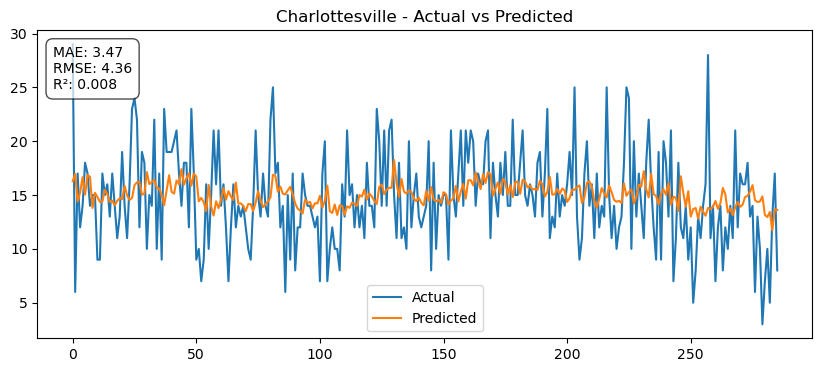


Processing city: Chicago


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
MAE: 41.84, RMSE: 52.71, R²: 0.412


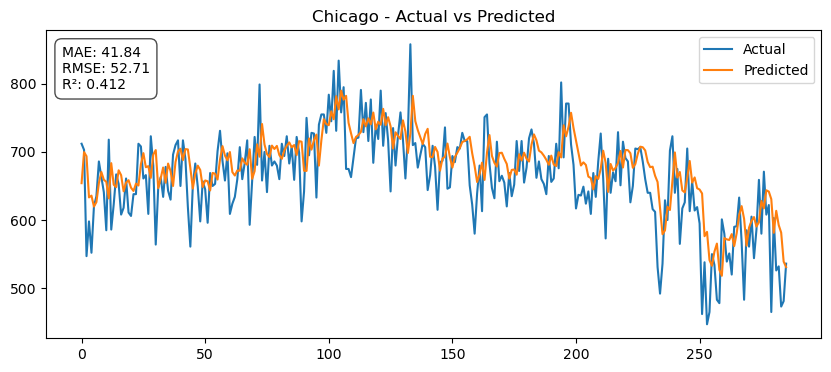


Processing city: Durham


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
MAE: 10.57, RMSE: 13.58, R²: 0.139


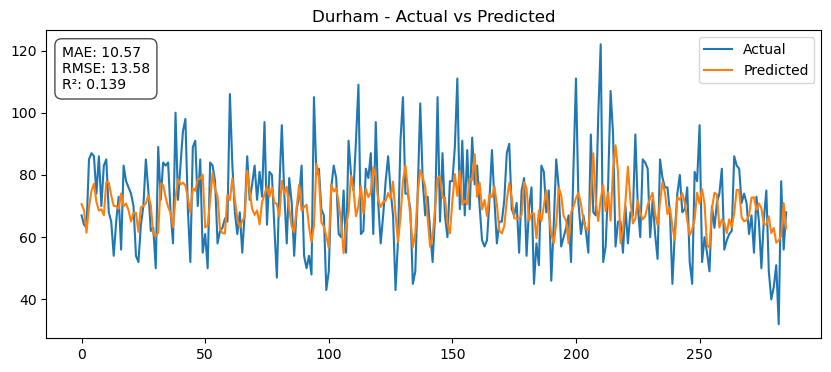


Processing city: NYC


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
MAE: 73.63, RMSE: 101.62, R²: 0.565


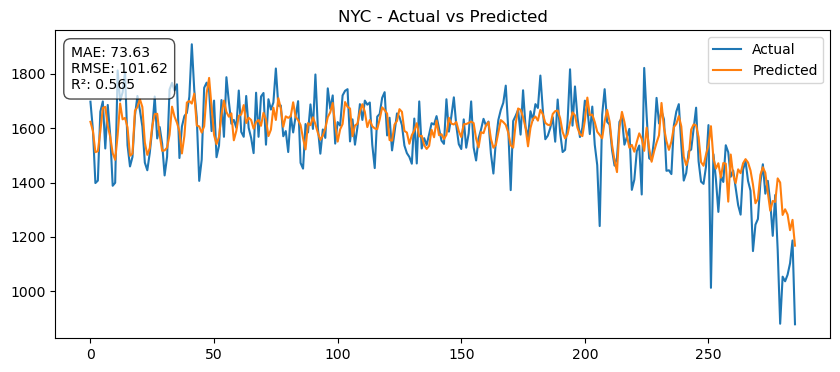


Overall Performance:
MAE     32.374255
RMSE    43.069303
R2       0.280851
dtype: float64

Per-City Results:
              city        MAE        RMSE        R2
0  Charlottesville   3.466445    4.364785  0.008018
1          Chicago  41.835022   52.714244  0.412147
2           Durham  10.565873   13.583034  0.138699
3              NYC  73.629681  101.615150  0.564538


In [82]:
features = ['total_crime_count']
# load data
df = pd.read_csv("weather_crime_final.csv")
df['date'] = pd.to_datetime(df['date'])

# helper functions
# create time sequences for RNN
def create_sequences(data, target_idx, seq_length=7):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_idx])
    return np.array(X), np.array(y)

# build the RNN model
def build_model(input_shape):
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# convert scaled predictions back to original values
def inverse_transform(preds, scaler, target_idx, n_features):
    temp = np.zeros((len(preds), n_features))
    temp[:, target_idx] = preds.flatten()
    return scaler.inverse_transform(temp)[:, target_idx]

# evaluate model performance
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# process each city 
def process_city(city_df):
    # train test split
    split = int(len(city_df) * 0.8)
    train, test = city_df.iloc[:split], city_df.iloc[split:]

    # scale features using MinMaxScaler
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[features])
    test_scaled = scaler.transform(test[features])

    # create sequences for RNN input
    target_idx = features.index('total_crime_count')
    X_train, y_train = create_sequences(train_scaled, target_idx)
    X_test, y_test = create_sequences(test_scaled, target_idx)

    # build and train model
    model = build_model((SEQ_LENGTH, len(features)))
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        shuffle=False,
        verbose=0
    )

    # make predictions, convert them back to original scale, and evaluate them
    y_pred = model.predict(X_test)
    y_pred_inv = inverse_transform(y_pred, scaler, target_idx, len(features))
    y_test_inv = inverse_transform(y_test.reshape(-1, 1), scaler, target_idx, len(features))
    metrics = evaluate(y_test_inv, y_pred_inv)
    
    return metrics, y_test_inv, y_pred_inv


results = []
for city, city_df in df.groupby('city'):
    print(f"\nProcessing city: {city}")
    metrics, y_true, y_pred = process_city(city_df)
    print(f"MAE: {metrics['MAE']:.2f}, RMSE: {metrics['RMSE']:.2f}, R²: {metrics['R2']:.3f}")
    results.append({"city": city, **metrics})

    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(f"{city} - Actual vs Predicted")
    plt.legend()
    
    # add metrics on the plot
    metric_text = f"MAE: {metrics['MAE']:.2f}\nRMSE: {metrics['RMSE']:.2f}\nR²: {metrics['R2']:.3f}"
    plt.text(
        0.02, 0.95, metric_text,
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
    )

    # save figure
    plt.savefig(f"Outputs/{city}crime_only.png", bbox_inches='tight')
    plt.show()

# results
results_df = pd.DataFrame(results)
print("\nOverall Performance:")
print(results_df.mean(numeric_only=True))
print("\nPer-City Results:")
print(results_df)